In [35]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import scipy
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

plt.style.use('matlab.mplstyle')

In [36]:
UR = np.genfromtxt(r"S:\1.FILE\eqn\tatra-eqn-ur.csv", delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
u = UR[: , 1]/30
r = UR[: , 2]/1e3

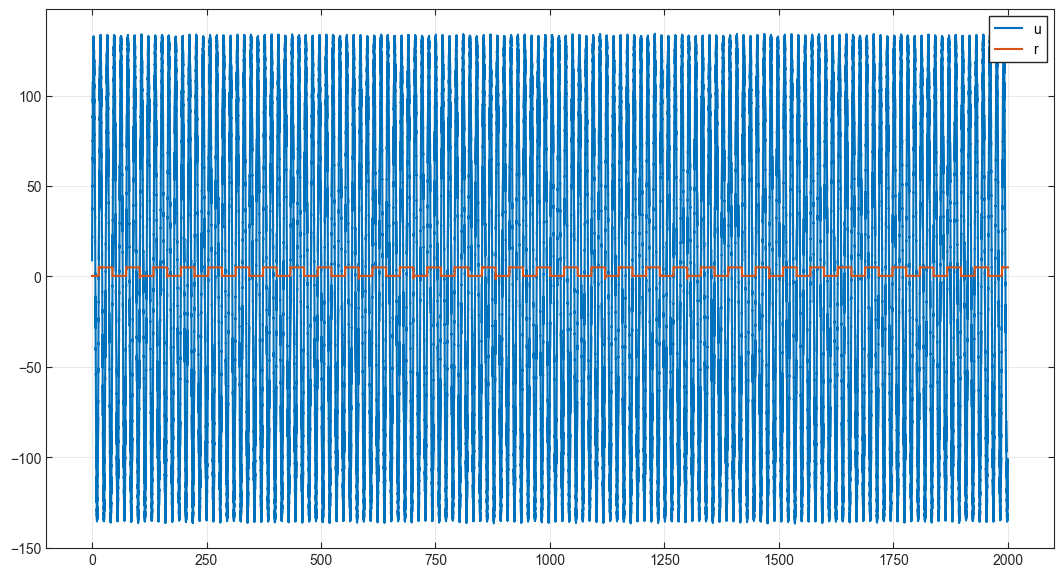

In [37]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(t, u, linewidth=1.5, label="u")
ax.plot(t, r, linewidth=1.5, label="r")

#ax.set_xlim([25, 35])
#ax.set_ylim([-6, 6])
ax.grid(True)
ax.legend()

plt.show()

První sestupná hrana nalezena v čase: 44.6129 s (index 46960)
[  46960  109859  172771  235701  298668  361598  424491  487377  550259
  613132  676050  738945  801882  864797  927731  990625 1053537 1116427
 1179314 1242218 1305139 1368071 1431013 1493912 1556806 1619670 1682559
 1745465 1808375 1871308 1934253 1997204 2060141]


(990.0, 1005.0)

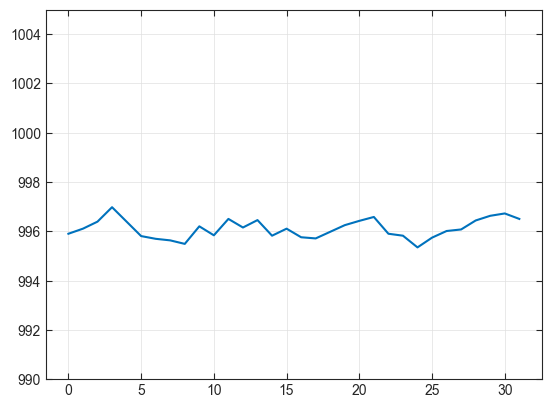

In [ ]:
d_r = np.diff(r)

# 2. Nastavení prahu a nalezení indexů (obdoba find)
prah = -2
indexy_poklesu = np.where(d_r < prah)[0]

# 3. Kontrola, zda pole není prázdné (obdoba isempty)
if indexy_poklesu.size == 0:
    raise ValueError("Žádná sestupná hrana nebyla nalezena! Zkontroluj nastavení prahu.")

rychlost = []
for i in range(len(indexy_poklesu)):
    rychlost.append((t[indexy_poklesu[i]]-t[indexy_poklesu[i-1]])*1000/60)
#print(rychlost[1:])
plt.plot(rychlost[1:])
plt.ylim(990,1005)